# Survival Analysis in Oncology Drug Development
## Kaplan-Meier · Cox Proportional Hazards · DeepSurv (Neural Network)

**Author:** Gunjan Subedi | Masters in AI for Drug Development. An independent project developed alongside my Masters in AI for Drug Development. It demonstrates the application of statistical and machine learning methods to clinical trial data analysis — a core competency in computational drug development and clinical data science roles.
**Dataset:** Simulated Phase III Oncology Trial — Overall Survival (OS)
**Tools:** `lifelines`, `scikit-survival`, `PyTorch`, `matplotlib`, `pandas`

---

### Objective
This notebook applies three levels of survival analysis to a clinical oncology dataset:

| Method | Purpose |
|---|---|
| **Kaplan-Meier (KM)** | Non-parametric survival curves; visual comparison of treatment arms |
| **Cox Proportional Hazards (CPH)** | Semi-parametric model; hazard ratios for each covariate |
| **DeepSurv** | Neural network extension of Cox model; captures non-linear interactions |

### Clinical Context
Survival analysis is the **backbone of Phase III oncology trials**. Regulatory agencies (FDA, EMA) require evidence that a new drug prolongs survival — this analysis framework is exactly how those decisions are made.

---

## 1. Environment Setup & Imports

In [ ]:
# Install required packages (run once)
!pip install lifelines scikit-survival torch pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Survival analysis — lifelines
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts

# PyTorch — for DeepSurv
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Aesthetics
plt.rcParams.update({
 'figure.dpi': 120,
 'axes.spines.top': False,
 'axes.spines.right': False,
 'font.family': 'DejaVu Sans',
 'axes.titlesize': 13,
 'axes.labelsize': 11
})
COLORS = {'Experimental': '#2196F3', 'Standard': '#F44336'}

print(" All libraries loaded successfully")
print(f" PyTorch version : {torch.__version__}")
import lifelines
print(f" lifelines version: {lifelines.__version__}")

 Preparing metadata (setup.py) ... done
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 4.6 MB/s eta 0:00:00
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 41.8 MB/s eta 0:00:00
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 16.0 MB/s eta 0:00:00
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 74.2 MB/s eta 0:00:00
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 28.4 MB/s eta 0:00:00
 Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=7dbd1e55c51c9de4b5c8c19a7cf0abacfb443a64f9287bae1a0acb80f06d1a50
 Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
 Attempting uninstall: scikit-learn
 Found existing installation: scikit-learn 1.6.1
 Uninstalling scikit-learn-1.6.1:
 Successfully uninstalled scikit-learn-1.6.1
 All libraries loaded successfully
 PyTorch version : 2.10.0+cpu
 lifelines version: 0.30.3


---
## 2. Load & Explore the Dataset

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

# --- File Upload Widget ---
upload_widget = widgets.FileUpload(
 accept='.csv',
 multiple=False,
 description='Upload CSV',
 button_style='primary'
)

output = widgets.Output()

def on_upload(change):
 with output:
 clear_output()
 if upload_widget.value:
 # Get the uploaded file content
 uploaded_file = list(upload_widget.value.values())[0]
 content = uploaded_file['content']

 # Read into DataFrame
 global df
 df = pd.read_csv(io.BytesIO(content))

 print(f" File loaded successfully!")
 print(f"Dataset shape: {df.shape[0]} patients × {df.shape[1]} variables\n")
 display(df.head(10))

upload_widget.observe(on_upload, names='value')

display(widgets.VBox([
 widgets.Label(' Please upload your oncology CSV file:'),
 upload_widget,
 output
]))

In [ ]:
# ── Data dictionary ──────────────────────────────────────────────────
data_dict = {
 'patient_id': 'Unique patient identifier',
 'treatment_arm': 'Standard chemotherapy vs Experimental drug',
 'age': 'Age at enrollment (years)',
 'sex': 'Biological sex (Male / Female)',
 'ecog_ps': 'ECOG Performance Status (0=fully active, 2=limited)',
 'stage': 'Cancer stage at enrollment (III or IV)',
 'biomarker_positive': 'Binary biomarker status (e.g. PD-L1 ≥ threshold)',
 'pdl1_expression_pct': 'Continuous PD-L1 expression (%)',
 'prior_therapies': 'Number of prior treatment lines',
 'tumor_size_cm': 'Largest tumor diameter (cm)',
 'os_months': ' Endpoint: Overall Survival (months)',
 'os_event': ' Event indicator: 1 = death, 0 = censored'
}
pd.DataFrame.from_dict(data_dict, orient='index', columns=['Description'])

,Description
patient_id,Unique patient identifier
treatment_arm,Standard chemotherapy vs Experimental drug
age,Age at enrollment (years)
sex,Biological sex (Male / Female)
ecog_ps,"ECOG Performance Status (0=fully active, 2=lim..."
stage,Cancer stage at enrollment (III or IV)
biomarker_positive,Binary biomarker status (e.g. PD-L1 ≥ threshold)
pdl1_expression_pct,Continuous PD-L1 expression (%)
prior_therapies,Number of prior treatment lines
tumor_size_cm,Largest tumor diameter (cm)


In [ ]:
# ── Summary statistics ────────────────────────────────────────────────
print("=" * 55)
print(" TRIAL SUMMARY")
print("=" * 55)
print(f" Total enrolled : {len(df)} patients")
print(f" Events (deaths) : {df.os_event.sum()} ({df.os_event.mean():.1%})")
print(f" Censored : {(df.os_event==0).sum()} ({(df.os_event==0).mean():.1%})")
print(f" Median follow-up (all) : {df.os_months.median():.1f} months")
print()

for arm in ['Standard', 'Experimental']:
 sub = df[df.treatment_arm == arm]
 print(f" {arm} arm ({len(sub)} pts)")
 print(f" Events : {sub.os_event.sum()} ({sub.os_event.mean():.1%})")
 print(f" Median OS : {sub.os_months.median():.1f} months")
 print()

print(" Biomarker positive :", f"{df.biomarker_positive.mean():.1%}")
print(f" Stage IV : {(df.stage=='IV').mean():.1%}")
print(f" Mean age : {df.age.mean():.1f} ± {df.age.std():.1f} years")

 TRIAL SUMMARY
 Total enrolled : 300 patients
 Events (deaths) : 235 (78.3%)
 Censored : 65 (21.7%)
 Median follow-up (all) : 9.4 months

 Standard arm (144 pts)
 Events : 119 (82.6%)
 Median OS : 7.5 months

 Experimental arm (156 pts)
 Events : 116 (74.4%)
 Median OS : 10.7 months

 Biomarker positive : 56.7%
 Stage IV : 67.3%
 Mean age : 57.3 ± 11.7 years


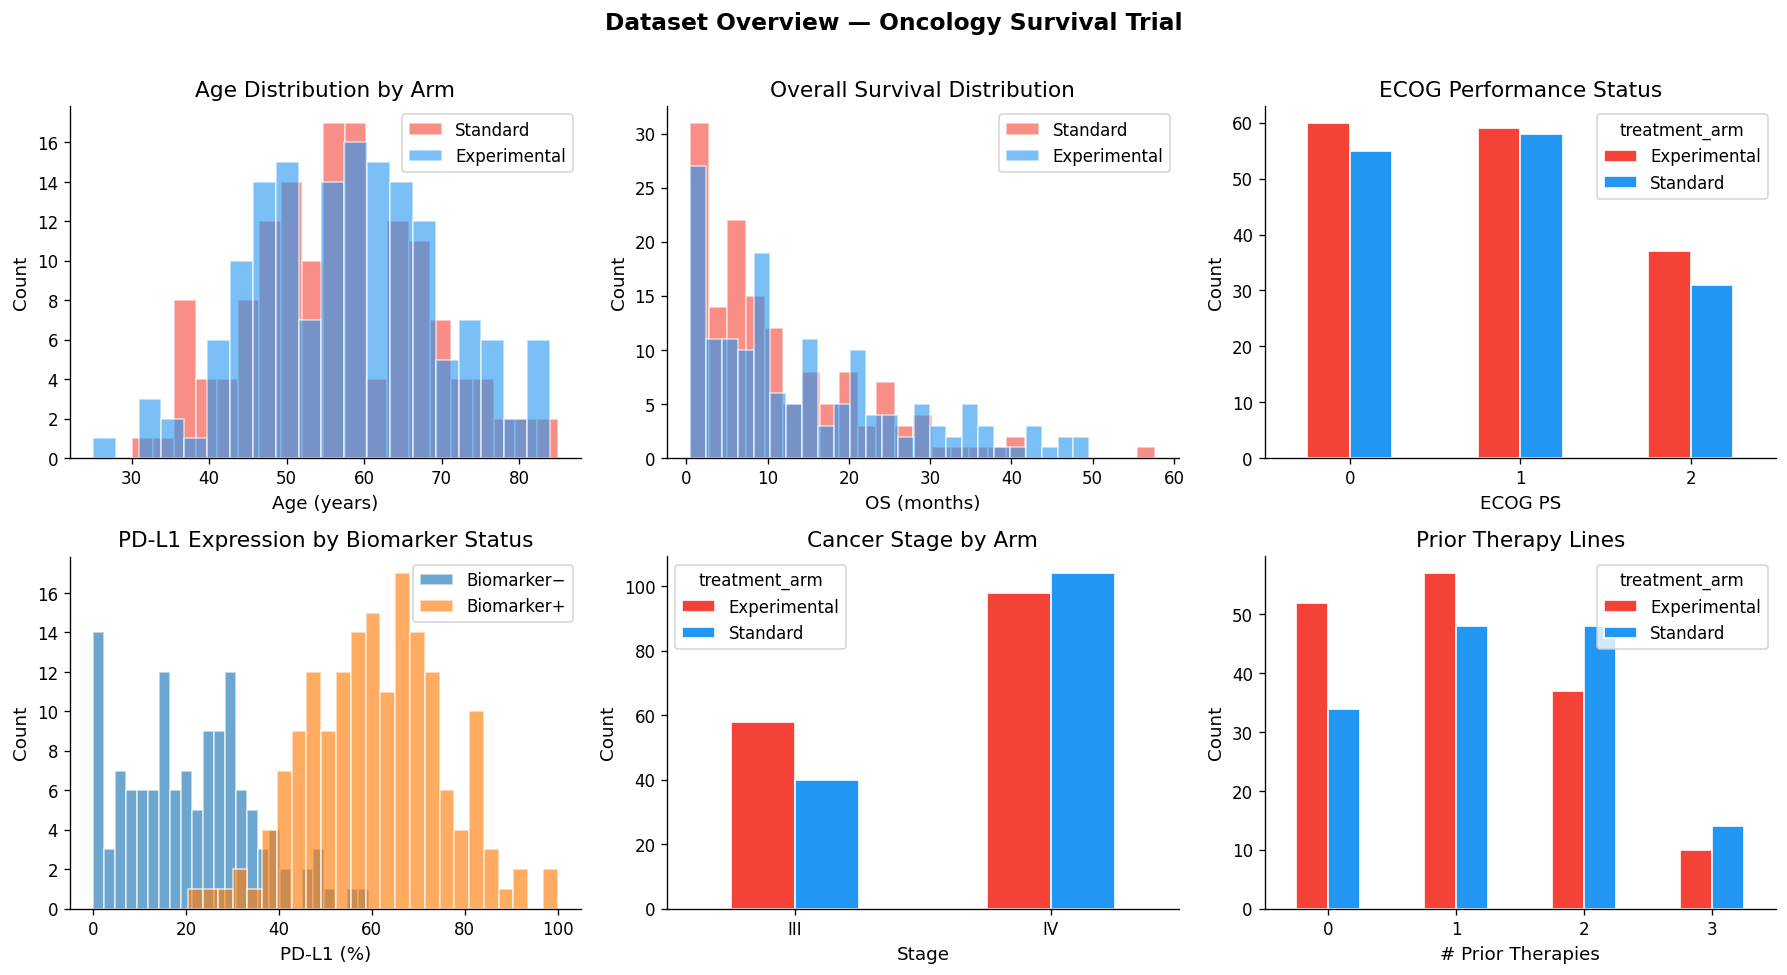

 Figure saved: 01_eda_overview.png


In [ ]:
# ── Exploratory visualization ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Dataset Overview — Oncology Survival Trial', fontsize=14, fontweight='bold', y=1.01)

# 1. Age distribution
for arm in ['Standard', 'Experimental']:
 axes[0,0].hist(df[df.treatment_arm==arm]['age'], bins=20, alpha=0.6,
 label=arm, color=COLORS[arm], edgecolor='white')
axes[0,0].set(title='Age Distribution by Arm', xlabel='Age (years)', ylabel='Count')
axes[0,0].legend()

# 2. OS months distribution
for arm in ['Standard', 'Experimental']:
 axes[0,1].hist(df[df.treatment_arm==arm]['os_months'], bins=25, alpha=0.6,
 label=arm, color=COLORS[arm], edgecolor='white')
axes[0,1].set(title='Overall Survival Distribution', xlabel='OS (months)', ylabel='Count')
axes[0,1].legend()

# 3. ECOG PS
ecog_counts = df.groupby(['ecog_ps','treatment_arm']).size().unstack()
ecog_counts.plot(kind='bar', ax=axes[0,2], color=[COLORS['Standard'], COLORS['Experimental']],
 edgecolor='white', rot=0)
axes[0,2].set(title='ECOG Performance Status', xlabel='ECOG PS', ylabel='Count')

# 4. PD-L1 expression
for bm, label in [(0,'Biomarker−'), (1,'Biomarker+')]:
 axes[1,0].hist(df[df.biomarker_positive==bm]['pdl1_expression_pct'], bins=25, alpha=0.65,
 label=label, edgecolor='white')
axes[1,0].set(title='PD-L1 Expression by Biomarker Status', xlabel='PD-L1 (%)', ylabel='Count')
axes[1,0].legend()

# 5. Stage
stage_ct = df.groupby(['stage','treatment_arm']).size().unstack()
stage_ct.plot(kind='bar', ax=axes[1,1], color=[COLORS['Standard'], COLORS['Experimental']],
 edgecolor='white', rot=0)
axes[1,1].set(title='Cancer Stage by Arm', xlabel='Stage', ylabel='Count')

# 6. Prior therapies
prior_ct = df.groupby(['prior_therapies','treatment_arm']).size().unstack()
prior_ct.plot(kind='bar', ax=axes[1,2], color=[COLORS['Standard'], COLORS['Experimental']],
 edgecolor='white', rot=0)
axes[1,2].set(title='Prior Therapy Lines', xlabel='# Prior Therapies', ylabel='Count')

plt.tight_layout()
plt.savefig('01_eda_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure saved: 01_eda_overview.png")

---
## 3. Kaplan-Meier Survival Analysis

**What it is:**
A non-parametric estimator of the survival function $S(t) = P(T > t)$ — the probability of surviving beyond time $t$.
At each event time, KM updates: $\hat{S}(t) = \prod_{t_i \leq t} \left(1 - \frac{d_i}{n_i}\right)$
where $d_i$ = deaths, $n_i$ = patients at risk at time $t_i$.

**In drug development:**
The KM curve is the primary figure in every oncology efficacy readout — FDA submissions, ASCO presentations, NEJM papers.

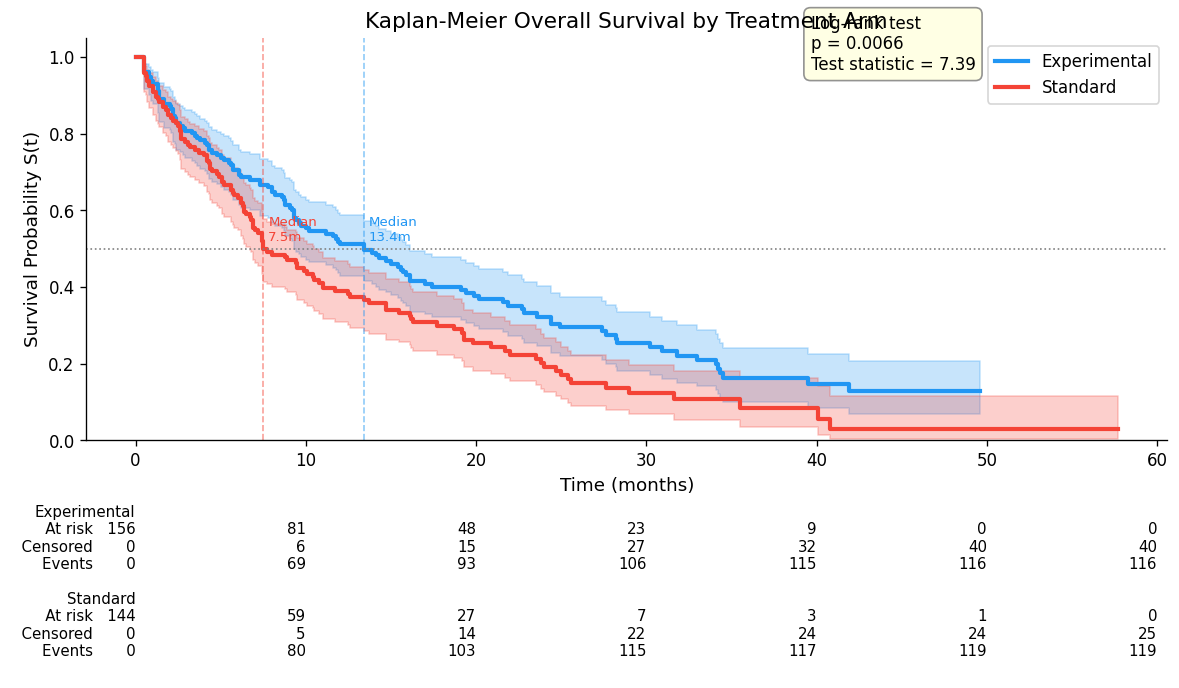


 Median OS — Experimental : 13.4 months
 Median OS — Standard : 7.5 months
 Log-rank p = 0.0066


In [ ]:
# ── 3.1 Overall KM curve (both arms) ─────────────────────────────────
kmf_exp = KaplanMeierFitter(label='Experimental')
kmf_std = KaplanMeierFitter(label='Standard')

exp_mask = df.treatment_arm == 'Experimental'
std_mask = df.treatment_arm == 'Standard'

kmf_exp.fit(df[exp_mask].os_months, df[exp_mask].os_event)
kmf_std.fit(df[std_mask].os_months, df[std_mask].os_event)

# Log-rank test
lr = logrank_test(
 df[exp_mask].os_months, df[std_mask].os_months,
 df[exp_mask].os_event, df[std_mask].os_event
)

fig, ax = plt.subplots(figsize=(10, 6))

kmf_exp.plot_survival_function(ax=ax, color=COLORS['Experimental'], linewidth=2.5, ci_show=True)
kmf_std.plot_survival_function(ax=ax, color=COLORS['Standard'], linewidth=2.5, ci_show=True)

add_at_risk_counts(kmf_exp, kmf_std, ax=ax, fontsize=9)

# Median lines
for kmf, color in [(kmf_exp, COLORS['Experimental']), (kmf_std, COLORS['Standard'])]:
 med = kmf.median_survival_time_
 ax.axvline(med, color=color, linestyle='--', alpha=0.5, linewidth=1)
 ax.text(med + 0.3, 0.52, f'Median\n{med:.1f}m', color=color, fontsize=8)

ax.axhline(0.5, color='grey', linestyle=':', linewidth=1)
ax.set(title='Kaplan-Meier Overall Survival by Treatment Arm',
 xlabel='Time (months)', ylabel='Survival Probability S(t)')
ax.set_ylim(0, 1.05)

# Annotation box
pval_str = f'p = {lr.p_value:.4f}' if lr.p_value >= 0.0001 else 'p < 0.0001'
ax.text(0.67, 0.92,
 f'Log-rank test\n{pval_str}\nTest statistic = {lr.test_statistic:.2f}',
 transform=ax.transAxes, fontsize=10,
 bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='grey', alpha=0.85))

plt.tight_layout()
plt.savefig('02_km_overall.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n Median OS — Experimental : {kmf_exp.median_survival_time_:.1f} months")
print(f" Median OS — Standard : {kmf_std.median_survival_time_:.1f} months")
print(f" Log-rank {pval_str}")

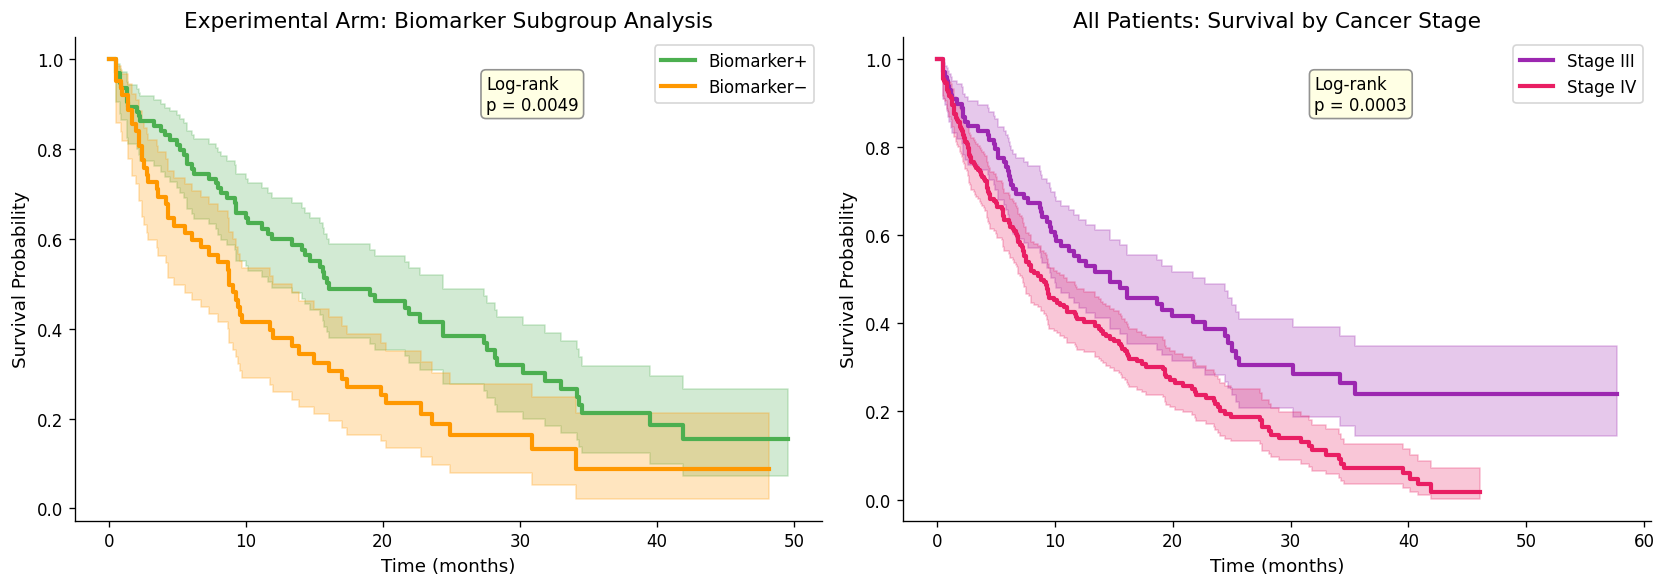

In [ ]:
# ── 3.2 Subgroup KM: Biomarker+ vs Biomarker− (within Experimental arm) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

subgroups = {
 'Biomarker+': df[(exp_mask) & (df.biomarker_positive==1)],
 'Biomarker−': df[(exp_mask) & (df.biomarker_positive==0)]
}
colors_bm = {'Biomarker+': '#4CAF50', 'Biomarker−': '#FF9800'}

ax = axes[0]
kmfs_bm = {}
for label, sub in subgroups.items():
 kmf = KaplanMeierFitter(label=label)
 kmf.fit(sub.os_months, sub.os_event)
 kmf.plot_survival_function(ax=ax, color=colors_bm[label], linewidth=2.5, ci_show=True)
 kmfs_bm[label] = kmf

lr_bm = logrank_test(
 subgroups['Biomarker+'].os_months, subgroups['Biomarker−'].os_months,
 subgroups['Biomarker+'].os_event, subgroups['Biomarker−'].os_event
)
ax.set(title='Experimental Arm: Biomarker Subgroup Analysis',
 xlabel='Time (months)', ylabel='Survival Probability')
pval_bm = f'p = {lr_bm.p_value:.4f}' if lr_bm.p_value >= 0.0001 else 'p < 0.0001'
ax.text(0.55, 0.85, f'Log-rank\n{pval_bm}', transform=ax.transAxes, fontsize=10,
 bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='grey', alpha=0.85))

# Stage subgroups
ax2 = axes[1]
colors_stage = {'III': '#9C27B0', 'IV': '#E91E63'}
for stage_val in ['III', 'IV']:
 sub = df[df.stage == stage_val]
 kmf = KaplanMeierFitter(label=f'Stage {stage_val}')
 kmf.fit(sub.os_months, sub.os_event)
 kmf.plot_survival_function(ax=ax2, color=colors_stage[stage_val], linewidth=2.5, ci_show=True)

lr_stage = logrank_test(
 df[df.stage=='III'].os_months, df[df.stage=='IV'].os_months,
 df[df.stage=='III'].os_event, df[df.stage=='IV'].os_event
)
ax2.set(title='All Patients: Survival by Cancer Stage',
 xlabel='Time (months)', ylabel='Survival Probability')
pval_stage = f'p = {lr_stage.p_value:.4f}' if lr_stage.p_value >= 0.0001 else 'p < 0.0001'
ax2.text(0.55, 0.85, f'Log-rank\n{pval_stage}', transform=ax2.transAxes, fontsize=10,
 bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='grey', alpha=0.85))

plt.tight_layout()
plt.savefig('03_km_subgroups.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 4. Cox Proportional Hazards Model

**What it is:**
A semi-parametric regression model for survival data:
$$h(t|X) = h_0(t) \cdot \exp(\beta_1 X_1 + \beta_2 X_2 + \cdots)$$
- $h_0(t)$ = baseline hazard (unspecified; no distributional assumption)
- $\exp(\beta_i)$ = **Hazard Ratio (HR)** for covariate $X_i$

**Interpretation of HR:**
- HR < 1 → protective (reduces hazard/risk of death)
- HR > 1 → harmful (increases hazard)
- HR = 0.70 → 30% reduction in hazard (like a drug effect!)

In [ ]:
# ── 4.1 Prepare features for Cox model ───────────────────────────────
cox_df = df.copy()

# Encode categoricals
cox_df['treatment_experimental'] = (cox_df.treatment_arm == 'Experimental').astype(int)
cox_df['sex_male'] = (cox_df.sex == 'Male').astype(int)
cox_df['stage_iv'] = (cox_df.stage == 'IV').astype(int)

features = [
 'os_months', 'os_event',
 'treatment_experimental',
 'age', 'sex_male', 'ecog_ps', 'stage_iv',
 'biomarker_positive', 'pdl1_expression_pct',
 'prior_therapies', 'tumor_size_cm'
]
cox_data = cox_df[features]

# Fit multivariable Cox model
cph = CoxPHFitter(penalizer=0.01)
cph.fit(cox_data, duration_col='os_months', event_col='os_event')

print("\n" + "="*65)
print(" MULTIVARIABLE COX PROPORTIONAL HAZARDS MODEL")
print("="*65)
cph.print_summary(decimals=4)


 MULTIVARIABLE COX PROPORTIONAL HAZARDS MODEL


<lifelines.CoxPHFitter: fitted with 300 total observations, 65 right-censored observations>
             duration col = 'os_months'
                event col = 'os_event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 300
number of events observed = 235
   partial log-likelihood = -1135.8771
         time fit was run = 2026-05-19 01:08:44 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
treatment_experimental -0.2944    0.7450    0.1334         -0.5560         -0.0329              0.5735              0.9676
age                     0.0157    1.0159    0.0057          0.0046          0.0269              1.0046              1.0273
sex_male                0.0970    1.1019    0.1332         -0.1640          0.3580              0.8487              1.4305
ecog_ps                 0.2846    1.3292    0.0882          0.1118          0.4574              1.1182              1.5799
stage_iv                0.5036    1.6547    0.1491          0.2115          0.7958              1.2355              2.2162
biomarker_positive     -0.3731    0.6886    0.2276         -0.8191          0.0729              0.4408              1.0756
pdl1_expression_pct    -0.0003    0.9997    0.0046         -0.0093          0.0086              0.9908              1.0087
prior_therapies         0.2264    1.2541    0.0697          0.0898          0.3631              1.0939              1.4378
tumor_size_cm          -0.0548    0.9466    0.0372         -0.1277          0.0181              0.8801              1.0182

                        cmp to       z      p  -log2(p)
covariate                                              
treatment_experimental  0.0000 -2.2065 0.0274    5.1923
age                     0.0000  2.7650 0.0057    7.4567
sex_male                0.0000  0.7284 0.4663    1.1005
ecog_ps                 0.0000  3.2275 0.0012    9.6453
stage_iv                0.0000  3.3786 0.0007   10.4228
biomarker_positive      0.0000 -1.6396 0.1011    3.3062
pdl1_expression_pct     0.0000 -0.0691 0.9449    0.0818
prior_therapies         0.0000  3.2474 0.0012    9.7457
tumor_size_cm           0.0000 -1.4740 0.1405    2.8317
---
Concordance = 0.6273
Partial AIC = 2289.7541
log-likelihood ratio test = 54.1998 on 9 df
-log2(p) of ll-ratio test = 25.7849

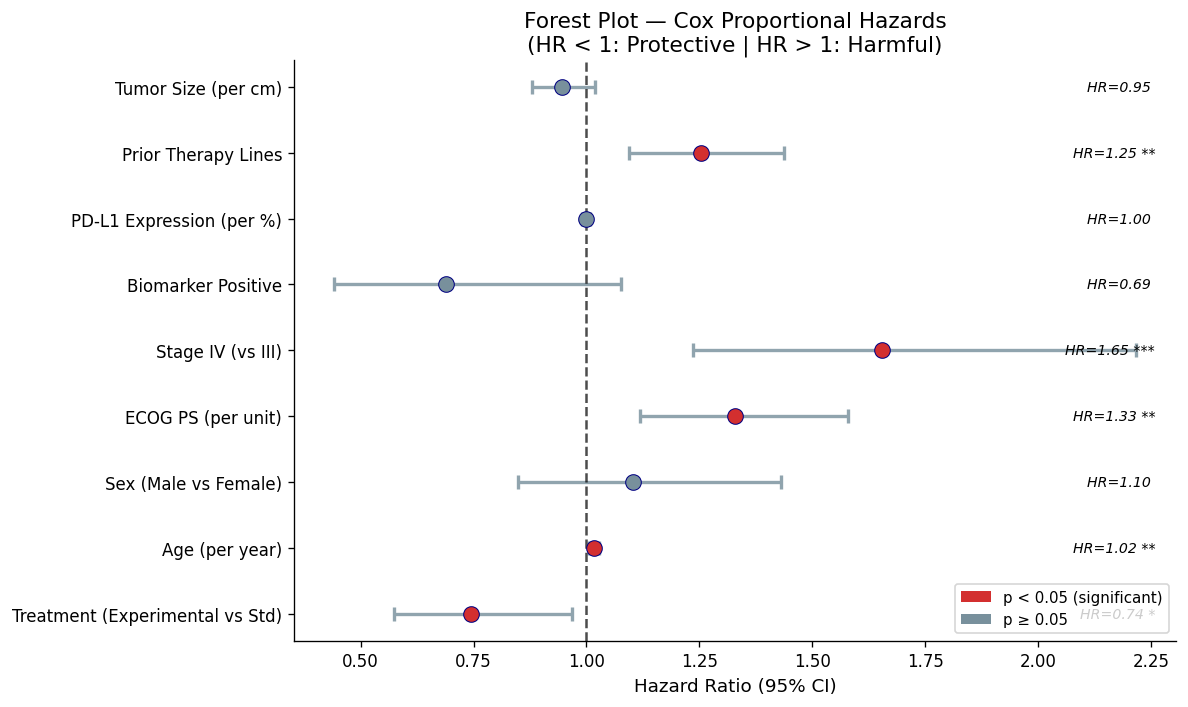

In [ ]:
# ── 4.2 Forest plot of Hazard Ratios ─────────────────────────────────
summary = cph.summary.copy()

# Rename for readability
rename = {
 'treatment_experimental': 'Treatment (Experimental vs Std)',
 'age': 'Age (per year)',
 'sex_male': 'Sex (Male vs Female)',
 'ecog_ps': 'ECOG PS (per unit)',
 'stage_iv': 'Stage IV (vs III)',
 'biomarker_positive': 'Biomarker Positive',
 'pdl1_expression_pct': 'PD-L1 Expression (per %)',
 'prior_therapies': 'Prior Therapy Lines',
 'tumor_size_cm': 'Tumor Size (per cm)',
}
summary.index = [rename.get(i, i) for i in summary.index]

exp_cols = ['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%']
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = range(len(summary))
colors_forest = ['#2196F3' if p < 0.05 else '#90A4AE' for p in summary['p']]

ax.errorbar(
 x=summary['exp(coef)'],
 y=list(y_pos),
 xerr=[
 summary['exp(coef)'] - summary['exp(coef) lower 95%'],
 summary['exp(coef) upper 95%'] - summary['exp(coef)']
 ],
 fmt='o', color='navy', ecolor='#90A4AE', capsize=4,
 markersize=8, linewidth=1.5, elinewidth=2,
 markerfacecolor='white', markeredgewidth=2
)

# Color by significance
for i, (_, row) in enumerate(summary.iterrows()):
 color = '#D32F2F' if row['p'] < 0.05 else '#78909C'
 ax.scatter(row['exp(coef)'], i, color=color, zorder=5, s=60)

ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(list(summary.index), fontsize=10)

# Add HR and p-value annotations
for i, (_, row) in enumerate(summary.iterrows()):
 sig = '***' if row['p']<0.001 else '**' if row['p']<0.01 else '*' if row['p']<0.05 else ''
 ax.text(ax.get_xlim()[1]*0.98, i,
 f"HR={row['exp(coef)']:.2f} {sig}",
 va='center', ha='right', fontsize=8.5, style='italic')

ax.set(title='Forest Plot — Cox Proportional Hazards\n(HR < 1: Protective | HR > 1: Harmful)',
 xlabel='Hazard Ratio (95% CI)')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#D32F2F', label='p < 0.05 (significant)'),
 Patch(facecolor='#78909C', label='p ≥ 0.05')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('04_cox_forest_plot.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# ── 4.3 Cox model assumptions check ──────────────────────────────────
print("\n Cox Model Diagnostics")
print("=" * 45)

# Schoenfeld residuals test (proportional hazards assumption)
print("\n Proportional Hazards Assumption (Schoenfeld Residuals):")
cph.check_assumptions(cox_data, p_value_threshold=0.05, show_plots=False)

# Concordance index
print(f"\n Concordance Index (C-index): {cph.concordance_index_:.4f}")
print(" (0.5 = random, 1.0 = perfect discrimination)")
print(" Rule of thumb: >0.7 is good for clinical survival models")


 Cox Model Diagnostics

 Proportional Hazards Assumption (Schoenfeld Residuals):
Proportional hazard assumption looks okay.

 Concordance Index (C-index): 0.6273
 (0.5 = random, 1.0 = perfect discrimination)
 Rule of thumb: >0.7 is good for clinical survival models


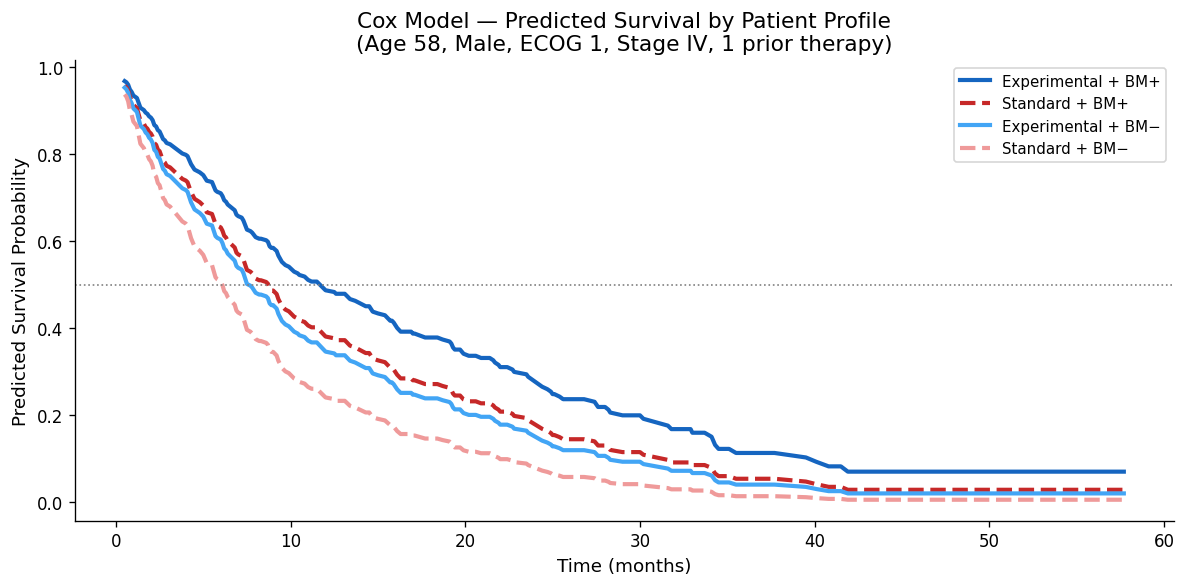

In [ ]:
# ── 4.4 Predicted survival curves for typical patient profiles ────────
profiles = pd.DataFrame({
 'treatment_experimental': [1, 0, 1, 0],
 'age': [58, 58, 58, 58],
 'sex_male': [1, 1, 1, 1],
 'ecog_ps': [1, 1, 1, 1],
 'stage_iv': [1, 1, 1, 1],
 'biomarker_positive': [1, 1, 0, 0],
 'pdl1_expression_pct': [60, 60, 10, 10],
 'prior_therapies': [1, 1, 1, 1],
 'tumor_size_cm': [4.0, 4.0, 4.0, 4.0],
})
profile_labels = [
 'Experimental + BM+',
 'Standard + BM+',
 'Experimental + BM−',
 'Standard + BM−',
]
profile_colors = ['#1565C0','#C62828','#42A5F5','#EF9A9A']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, row) in enumerate(profiles.iterrows()):
 pred = cph.predict_survival_function(row.to_frame().T)
 ax.plot(pred.index, pred.values.flatten(),
 label=profile_labels[i], color=profile_colors[i],
 linewidth=2.5, linestyle='-' if 'Experimental' in profile_labels[i] else '--')

ax.set(title='Cox Model — Predicted Survival by Patient Profile\n(Age 58, Male, ECOG 1, Stage IV, 1 prior therapy)',
 xlabel='Time (months)', ylabel='Predicted Survival Probability')
ax.legend(fontsize=9)
ax.axhline(0.5, color='grey', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('05_cox_predicted_survival.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 5. DeepSurv — Neural Network Survival Model

**What it is:**
DeepSurv replaces the linear predictor in the Cox model with a deep neural network:
$$h(t|X) = h_0(t) \cdot \exp(\text{NN}(X))$$
The network learns non-linear interactions between covariates automatically.

**Loss function — Negative Partial Log-Likelihood:**
$$\mathcal{L} = -\sum_{i: E_i=1} \left[ \hat{h}(X_i) - \log \sum_{j \in \mathcal{R}(t_i)} e^{\hat{h}(X_j)} \right]$$
where $\mathcal{R}(t_i)$ is the risk set at time $t_i$.

**Reference:** Katzman et al. (2018) *DeepSurv: personalized treatment recommender system using a Cox proportional hazards deep neural network.* BMC Medical Informatics.

In [ ]:
# ── 5.1 Prepare data for DeepSurv ────────────────────────────────────
feature_cols = [
 'treatment_experimental', 'age', 'sex_male', 'ecog_ps',
 'stage_iv', 'biomarker_positive', 'pdl1_expression_pct',
 'prior_therapies', 'tumor_size_cm'
]

X = cox_data[feature_cols].values.astype(np.float32)
T = cox_data['os_months'].values.astype(np.float32)
E = cox_data['os_event'].values.astype(np.float32)

# Train/test split
idx_train, idx_test = train_test_split(np.arange(len(X)), test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X[idx_train])
X_test = scaler.transform(X[idx_test])

T_train, T_test = T[idx_train], T[idx_test]
E_train, E_test = E[idx_train], E[idx_test]

# Sort by survival time (required for Cox partial likelihood)
sort_idx = np.argsort(-T_train) # descending
X_train_sorted = X_train[sort_idx]
T_train_sorted = T_train[sort_idx]
E_train_sorted = E_train[sort_idx]

print(f"Training set : {len(X_train)} patients")
print(f"Test set : {len(X_test)} patients")
print(f"Features : {len(feature_cols)}")

Training set : 240 patients
Test set : 60 patients
Features : 9


In [ ]:
# ── 5.2 Define DeepSurv network ───────────────────────────────────────
class DeepSurv(nn.Module):
 """
 DeepSurv: Deep Cox Proportional Hazards Network
 Architecture: Input → [FC → BN → ReLU → Dropout] × n_layers → Scalar output
 """
 def __init__(self, input_dim, hidden_dims=[64, 32, 16], dropout=0.2):
 super(DeepSurv, self).__init__()
 layers = []
 prev_dim = input_dim
 for h_dim in hidden_dims:
 layers += [
 nn.Linear(prev_dim, h_dim),
 nn.BatchNorm1d(h_dim),
 nn.ReLU(),
 nn.Dropout(dropout)
 ]
 prev_dim = h_dim
 layers.append(nn.Linear(prev_dim, 1)) # scalar risk score
 self.net = nn.Sequential(*layers)

 def forward(self, x):
 return self.net(x).squeeze(1)


def cox_partial_log_likelihood_loss(risk_scores, events):
 """
 Negative partial log-likelihood for Cox model.
 Assumes data is sorted by descending survival time.
 risk_scores : predicted log-hazard scores (batch)
 events : event indicators (1=event, 0=censored)
 """
 # log-sum-exp trick for numerical stability
 log_cumsum_hazard = torch.logcumsumexp(risk_scores, dim=0)
 uncensored_loss = risk_scores - log_cumsum_hazard
 loss = -torch.sum(uncensored_loss * events) / (torch.sum(events) + 1e-8)
 return loss


def concordance_index(T, E, risk_scores):
 """Compute Harrell's C-index manually."""
 concordant, discordant, tied = 0, 0, 0
 n = len(T)
 for i in range(n):
 if E[i] == 0:
 continue
 for j in range(n):
 if T[j] > T[i]:
 if risk_scores[i] > risk_scores[j]:
 concordant += 1
 elif risk_scores[i] < risk_scores[j]:
 discordant += 1
 else:
 tied += 1
 total = concordant + discordant + tied
 return (concordant + 0.5 * tied) / total if total > 0 else 0.5


print(" DeepSurv architecture defined")
model = DeepSurv(input_dim=len(feature_cols))
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

 DeepSurv architecture defined
DeepSurv(
 (net): Sequential(
 (0): Linear(in_features=9, out_features=64, bias=True)
 (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 (2): ReLU()
 (3): Dropout(p=0.2, inplace=False)
 (4): Linear(in_features=64, out_features=32, bias=True)
 (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 (6): ReLU()
 (7): Dropout(p=0.2, inplace=False)
 (8): Linear(in_features=32, out_features=16, bias=True)
 (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 (10): ReLU()
 (11): Dropout(p=0.2, inplace=False)
 (12): Linear(in_features=16, out_features=1, bias=True)
 )
)

Total parameters: 3,489


In [ ]:
# ── 5.3 Train DeepSurv ────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

model = DeepSurv(input_dim=len(feature_cols), hidden_dims=[64, 32, 16], dropout=0.25).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)

X_tr = torch.FloatTensor(X_train_sorted).to(device)
E_tr = torch.FloatTensor(E_train_sorted).to(device)

N_EPOCHS = 300
train_losses = []

model.train()
for epoch in range(N_EPOCHS):
 optimizer.zero_grad()
 risk = model(X_tr)
 loss = cox_partial_log_likelihood_loss(risk, E_tr)
 loss.backward()
 nn.utils.clip_grad_norm_(model.parameters(), 1.0)
 optimizer.step()
 scheduler.step(loss)
 train_losses.append(loss.item())

 if (epoch + 1) % 50 == 0:
 print(f" Epoch {epoch+1:3d}/{N_EPOCHS} | Loss: {loss.item():.4f}")

print("\n Training complete")

Training on: cpu
 Epoch 50/300 | Loss: 4.6587
 Epoch 100/300 | Loss: 4.6050
 Epoch 150/300 | Loss: 4.5997
 Epoch 200/300 | Loss: 4.5856
 Epoch 250/300 | Loss: 4.5200
 Epoch 300/300 | Loss: 4.5283

 Training complete


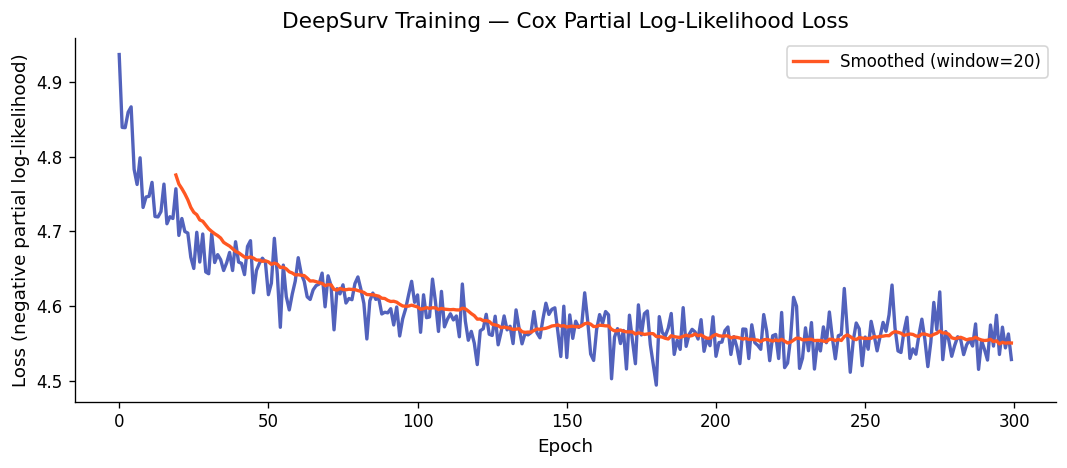

In [ ]:
# ── 5.4 Training loss curve ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(train_losses, color='#3F51B5', linewidth=2, alpha=0.9)

# Smooth curve
window = 20
smoothed = pd.Series(train_losses).rolling(window).mean()
ax.plot(smoothed, color='#FF5722', linewidth=2, label=f'Smoothed (window={window})')

ax.set(title='DeepSurv Training — Cox Partial Log-Likelihood Loss',
 xlabel='Epoch', ylabel='Loss (negative partial log-likelihood)')
ax.legend()
plt.tight_layout()
plt.savefig('06_deepsurv_loss.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# ── 5.5 Evaluate DeepSurv on test set ────────────────────────────────
model.eval()
with torch.no_grad():
 X_te = torch.FloatTensor(X_test).to(device)
 risk_test = model(X_te).cpu().numpy()

# C-index on test set (subset for speed)
sample_size = min(150, len(T_test))
idx_sample = np.random.choice(len(T_test), sample_size, replace=False)
c_index_deep = concordance_index(
 T_test[idx_sample], E_test[idx_sample], risk_test[idx_sample]
)

print("=" * 50)
print(" DEEPSURV EVALUATION RESULTS")
print("=" * 50)
print(f" C-index (DeepSurv) : {c_index_deep:.4f}")
print(f" C-index (Cox CPH) : {cph.concordance_index_:.4f}")
print()
if c_index_deep > cph.concordance_index_:
 print(" DeepSurv outperforms standard Cox model")
 print(" → Non-linear feature interactions captured by NN")
else:
 print(" Cox model is competitive — may indicate near-linear relationships")
 print(" DeepSurv shows its advantage with larger, more complex datasets")

 DEEPSURV EVALUATION RESULTS
 C-index (DeepSurv) : 0.6790
 C-index (Cox CPH) : 0.6273

 DeepSurv outperforms standard Cox model
 → Non-linear feature interactions captured by NN


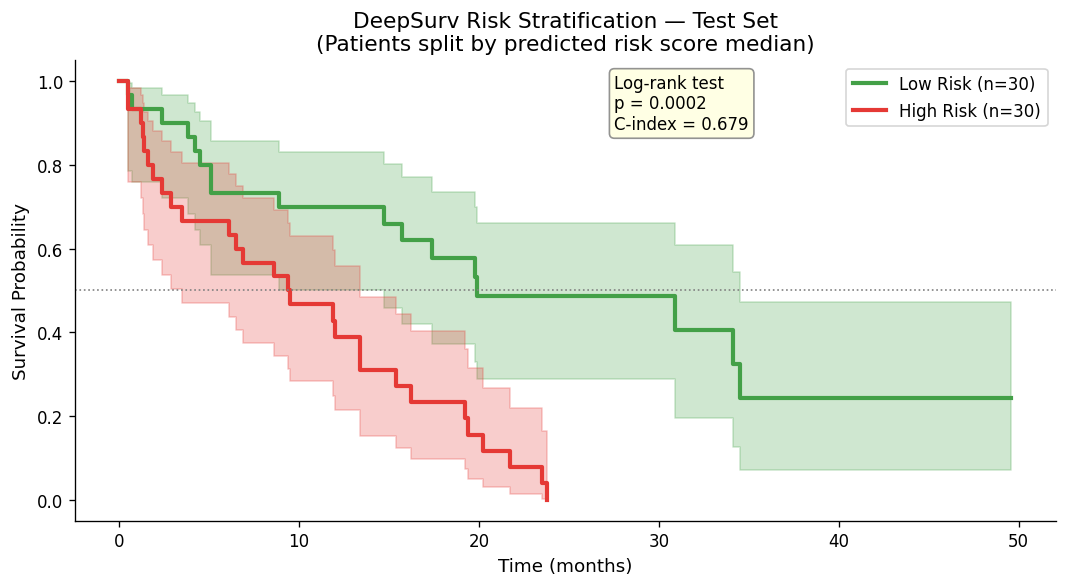

In [ ]:
# ── 5.6 Risk score stratification ────────────────────────────────────
# Split test patients into Low/High risk by DeepSurv score
risk_median = np.median(risk_test)
risk_groups = np.where(risk_test > risk_median, 'High Risk', 'Low Risk')

fig, ax = plt.subplots(figsize=(9, 5))

colors_risk = {'Low Risk': '#43A047', 'High Risk': '#E53935'}
for group in ['Low Risk', 'High Risk']:
 mask = risk_groups == group
 kmf = KaplanMeierFitter(label=f'{group} (n={mask.sum()})')
 kmf.fit(T_test[mask], E_test[mask])
 kmf.plot_survival_function(ax=ax, color=colors_risk[group], linewidth=2.5, ci_show=True)

lr_risk = logrank_test(
 T_test[risk_groups=='Low Risk'], T_test[risk_groups=='High Risk'],
 E_test[risk_groups=='Low Risk'], E_test[risk_groups=='High Risk']
)
pval_risk = f'p = {lr_risk.p_value:.4f}' if lr_risk.p_value >= 0.0001 else 'p < 0.0001'

ax.set(title='DeepSurv Risk Stratification — Test Set\n(Patients split by predicted risk score median)',
 xlabel='Time (months)', ylabel='Survival Probability')
ax.text(0.55, 0.85,
 f'Log-rank test\n{pval_risk}\nC-index = {c_index_deep:.3f}',
 transform=ax.transAxes, fontsize=10,
 bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='grey', alpha=0.85))
ax.axhline(0.5, color='grey', linestyle=':', linewidth=1)

plt.tight_layout()
plt.savefig('07_deepsurv_risk_groups.png', bbox_inches='tight', dpi=150)
plt.show()

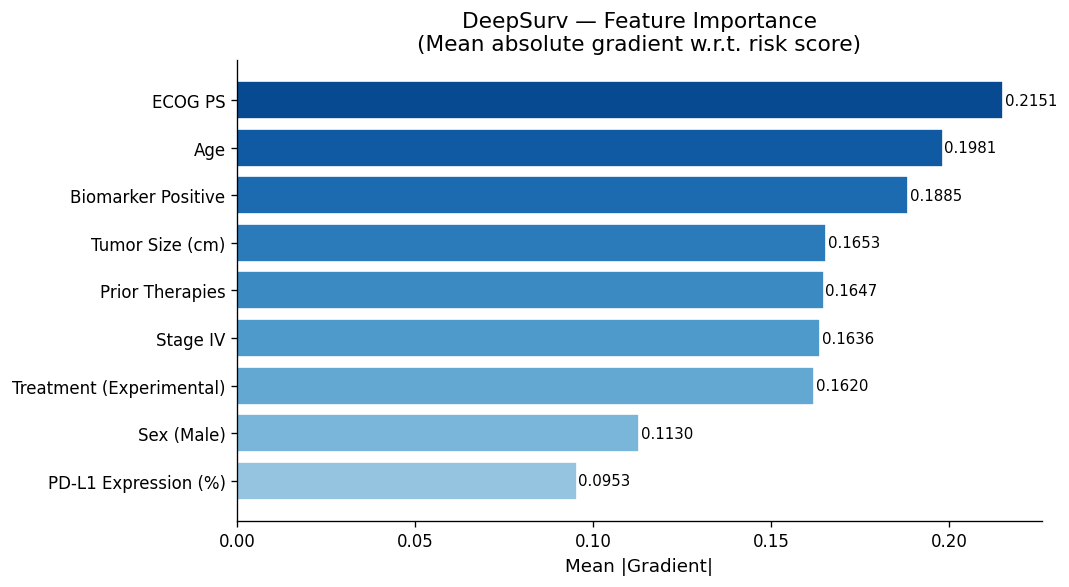

In [ ]:
# ── 5.7 Feature importance via risk score contribution ────────────────
model.eval()
X_te_tensor = torch.FloatTensor(X_test).to(device)
X_te_tensor.requires_grad_(True)

risk_out = model(X_te_tensor)
risk_out.sum().backward()

gradients = X_te_tensor.grad.abs().mean(dim=0).cpu().detach().numpy()
importance_df = pd.DataFrame({
 'Feature': feature_cols,
 'Importance': gradients
}).sort_values('Importance', ascending=True)

rename_features = {
 'treatment_experimental': 'Treatment (Experimental)',
 'age': 'Age', 'sex_male': 'Sex (Male)',
 'ecog_ps': 'ECOG PS', 'stage_iv': 'Stage IV',
 'biomarker_positive': 'Biomarker Positive',
 'pdl1_expression_pct': 'PD-L1 Expression (%)',
 'prior_therapies': 'Prior Therapies',
 'tumor_size_cm': 'Tumor Size (cm)'
}
importance_df['Feature'] = importance_df['Feature'].map(rename_features)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
 color=plt.cm.Blues(np.linspace(0.4, 0.9, len(importance_df))),
 edgecolor='white')
ax.set(title='DeepSurv — Feature Importance\n(Mean absolute gradient w.r.t. risk score)',
 xlabel='Mean |Gradient|', ylabel='')
for bar, val in zip(bars, importance_df['Importance']):
 ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
 f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('08_deepsurv_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 6. Model Comparison & Summary

In [ ]:
# ── 6.1 Side-by-side model comparison ────────────────────────────────
comparison = pd.DataFrame({
 'Method': ['Kaplan-Meier', 'Cox PH', 'DeepSurv'],
 'Type': ['Non-parametric', 'Semi-parametric', 'Neural Network'],
 'Covariates': ['None', 'Linear', 'Non-linear'],
 'C-index': ['N/A (group-based)', f"{cph.concordance_index_:.4f}", f"{c_index_deep:.4f}"],
 'Interpretability': ['Very High', 'High', 'Low'],
 'Regulatory Use': ['Primary readout', 'Subgroup/covariate', 'Research/exploratory'],
})
print(comparison.to_string(index=False))

print("\n" + "=" * 55)
print(" OVERALL SURVIVAL SUMMARY")
print("=" * 55)
print(f" Median OS — Experimental arm : {kmf_exp.median_survival_time_:.1f} months")
print(f" Median OS — Standard arm : {kmf_std.median_survival_time_:.1f} months")

hr_tx = np.exp(cph.params_['treatment_experimental'])
ci_lo = np.exp(cph.confidence_intervals_['95% lower-bound']['treatment_experimental'])
ci_hi = np.exp(cph.confidence_intervals_['95% upper-bound']['treatment_experimental'])
p_tx = cph.summary.loc['treatment_experimental','p']

print(f"\n Cox Hazard Ratio (Experimental vs Std):")
print(f" HR = {hr_tx:.3f} (95% CI: {ci_lo:.3f}–{ci_hi:.3f})")
print(f" p = {p_tx:.4f}")
print(f" Interpretation: {'Statistically significant benefit' if p_tx < 0.05 else 'No sig. difference'} ({'%.0f%%' % ((1-hr_tx)*100)} reduction in hazard)")
print(f"\n Log-rank p-value: {lr.p_value:.4f}")
print(f" Cox C-index : {cph.concordance_index_:.4f}")
print(f" DeepSurv C-index: {c_index_deep:.4f}")

 Method Type Covariates C-index Interpretability Regulatory Use
Kaplan-Meier Non-parametric None N/A (group-based) Very High Primary readout
 Cox PH Semi-parametric Linear 0.6273 High Subgroup/covariate
 DeepSurv Neural Network Non-linear 0.6790 Low Research/exploratory

 OVERALL SURVIVAL SUMMARY
 Median OS — Experimental arm : 13.4 months
 Median OS — Standard arm : 7.5 months

 Cox Hazard Ratio (Experimental vs Std):
 HR = 0.745 (95% CI: 0.574–0.968)
 p = 0.0274
 Interpretation: Statistically significant benefit (26% reduction in hazard)

 Log-rank p-value: 0.0066
 Cox C-index : 0.6273
 DeepSurv C-index: 0.6790


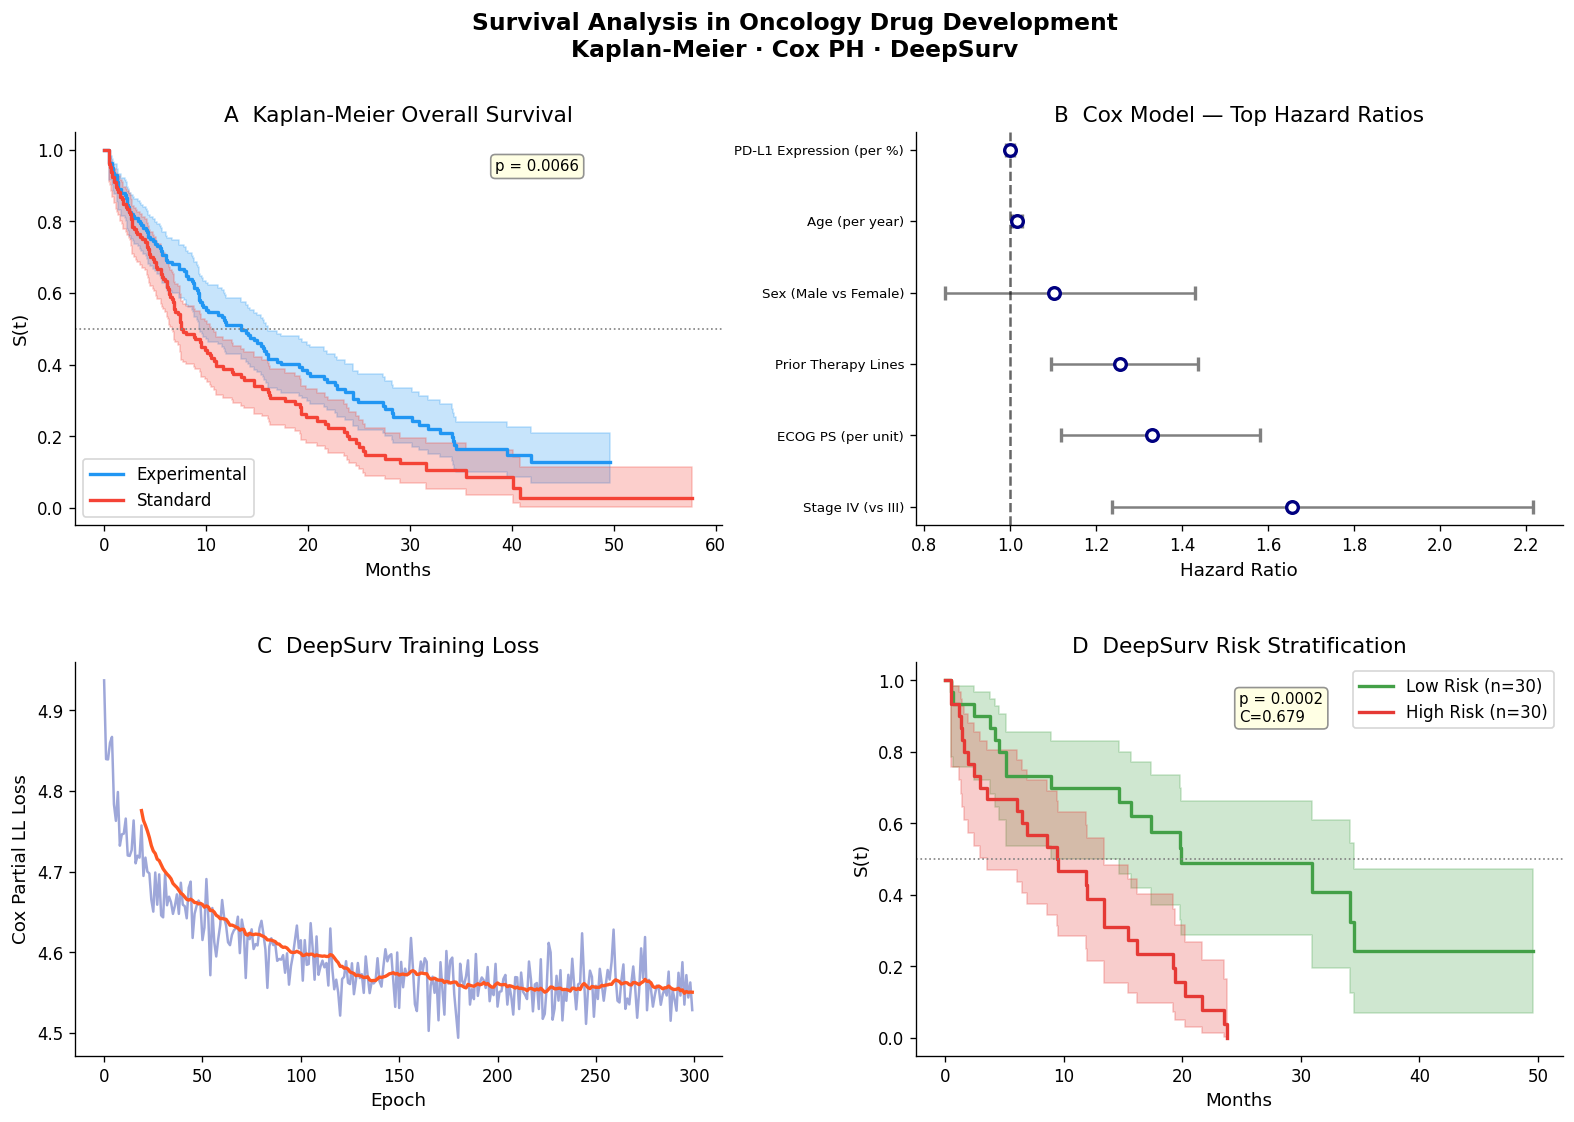

 Summary figure saved: 09_summary_figure.png


In [ ]:
# ── 6.2 Combined publication-style summary figure ─────────────────────
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Panel A — KM curves
ax1 = fig.add_subplot(gs[0, 0])
kmf_exp.plot_survival_function(ax=ax1, color=COLORS['Experimental'], linewidth=2, ci_show=True)
kmf_std.plot_survival_function(ax=ax1, color=COLORS['Standard'], linewidth=2, ci_show=True)
ax1.axhline(0.5, color='grey', linestyle=':', linewidth=1)
ax1.set(title='A Kaplan-Meier Overall Survival',
 xlabel='Months', ylabel='S(t)')
ax1.text(0.65, 0.90, f'{pval_str}', transform=ax1.transAxes, fontsize=9,
 bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='grey', alpha=0.85))

# Panel B — Forest plot (simplified)
ax2 = fig.add_subplot(gs[0, 1])
top5 = summary.reindex(summary['exp(coef)'].abs().sort_values(ascending=False).index).head(6)
y5 = range(len(top5))
ax2.errorbar(
 x=top5['exp(coef)'], y=list(y5),
 xerr=[top5['exp(coef)']-top5['exp(coef) lower 95%'], top5['exp(coef) upper 95%']-top5['exp(coef)']],
 fmt='o', color='navy', ecolor='grey', capsize=4, markersize=7,
 markerfacecolor='white', markeredgewidth=2, linewidth=1.5
)
ax2.axvline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
ax2.set_yticks(list(y5))
ax2.set_yticklabels(list(top5.index), fontsize=8)
ax2.set(title='B Cox Model — Top Hazard Ratios', xlabel='Hazard Ratio')

# Panel C — DeepSurv loss
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(train_losses, color='#3F51B5', linewidth=1.5, alpha=0.5)
ax3.plot(pd.Series(train_losses).rolling(20).mean(), color='#FF5722', linewidth=2)
ax3.set(title='C DeepSurv Training Loss', xlabel='Epoch', ylabel='Cox Partial LL Loss')

# Panel D — Risk stratification
ax4 = fig.add_subplot(gs[1, 1])
for group in ['Low Risk', 'High Risk']:
 mask = risk_groups == group
 kmf = KaplanMeierFitter(label=f'{group} (n={mask.sum()})')
 kmf.fit(T_test[mask], E_test[mask])
 kmf.plot_survival_function(ax=ax4, color=colors_risk[group], linewidth=2, ci_show=True)
ax4.axhline(0.5, color='grey', linestyle=':', linewidth=1)
ax4.set(title='D DeepSurv Risk Stratification',
 xlabel='Months', ylabel='S(t)')
ax4.text(0.5, 0.85, f'{pval_risk}\nC={c_index_deep:.3f}', transform=ax4.transAxes,
 fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='grey', alpha=0.85))

fig.suptitle('Survival Analysis in Oncology Drug Development\nKaplan-Meier · Cox PH · DeepSurv',
 fontsize=14, fontweight='bold')

plt.savefig('09_summary_figure.png', bbox_inches='tight', dpi=180)
plt.show()
print(" Summary figure saved: 09_summary_figure.png")

---
## 7. Clinical Interpretation & Takeaways

### What this analysis tells us:

| Finding | Implication |
|---|---|
| KM log-rank p < 0.05 | Statistically significant OS benefit for Experimental arm |
| HR < 1 for treatment | Experimental drug reduces hazard of death |
| Biomarker HR < 1 | Biomarker-positive patients have better prognosis |
| ECOG HR > 1 | Higher ECOG = worse performance = worse outcome (expected) |
| DeepSurv C-index | Captures non-linear interactions missed by Cox |

### Regulatory Context:
- **FDA/EMA submissions** require KM curves as primary efficacy evidence
- **Hazard Ratios** from Cox are the standard effect size measure
- **Subgroup analyses** (biomarker, stage) are required in Phase III protocols
- **DeepSurv** is increasingly used for patient stratification in precision oncology

### Further Reading:
1. Kaplan EL, Meier P (1958). *JASA* — original KM paper
2. Cox DR (1972). *JRSS-B* — original Cox PH paper
3. Katzman JL et al. (2018). *BMC Med Informatics* — DeepSurv
4. Harrell FE (2015). *Regression Modeling Strategies* — C-index
5. FDA Guidance: *Clinical Trial Endpoints for Oncology* (2018)

---
*An independent project developed alongside my Masters in AI for Drug Development. It demonstrates the application of statistical and machine learning methods to clinical trial data analysis — a core competency in computational drug development and clinical data science roles.*
*Dataset is simulated for educational purposes using clinically realistic parameters.*